In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
weather = pd.read_csv(r"D:\SHIROZ\Downloads\Weather dataset.csv")

In [3]:
weather.columns

Index(['Pressure', 'global_radiation', 'temp_mean(c)', 'temp_min(c)',
       'temp_max(c)', 'Wind_Speed', 'Wind_Bearing', 'normalized_label'],
      dtype='object')

In [4]:
weather.isnull().sum()

Pressure            0
global_radiation    0
temp_mean(c)        0
temp_min(c)         0
temp_max(c)         0
Wind_Speed          0
Wind_Bearing        0
normalized_label    0
dtype: int64

In [5]:
weather.describe()

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
count,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000
mean,1011.436192,1.310346,12.646057,8.648474,16.871960,11.885974,192.501742,0.906152
std,3.241187,0.897191,6.519240,5.867740,7.692881,7.677086,101.984936,0.992549
min,971.500000,0.030000,-11.100000,-16.000000,-8.500000,0.000000,0.000000,0.000000
25%,1009.800000,0.510000,7.800000,4.500000,11.100000,6.410000,130.000000,0.000000
50%,1012.300000,1.160000,13.200000,9.400000,17.200000,11.040000,190.000000,1.000000
75%,1013.900000,2.010000,17.500000,13.300000,22.400000,15.620000,288.000000,2.000000
max,1015.000000,3.600000,28.600000,22.000000,37.000000,47.530000,359.000000,3.000000


In [6]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533312 entries, 0 to 533311
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Pressure          533312 non-null  float64
 1   global_radiation  533312 non-null  float64
 2   temp_mean(c)      533312 non-null  float64
 3   temp_min(c)       533312 non-null  float64
 4   temp_max(c)       533312 non-null  float64
 5   Wind_Speed        533312 non-null  float64
 6   Wind_Bearing      533312 non-null  int64  
 7   normalized_label  533312 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 32.6 MB


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [11]:
X = weather[["Pressure", "global_radiation", "temp_mean(c)", "temp_min(c)", "temp_max(c)", "Wind_Speed", "Wind_Bearing"]]
y = weather["normalized_label"]

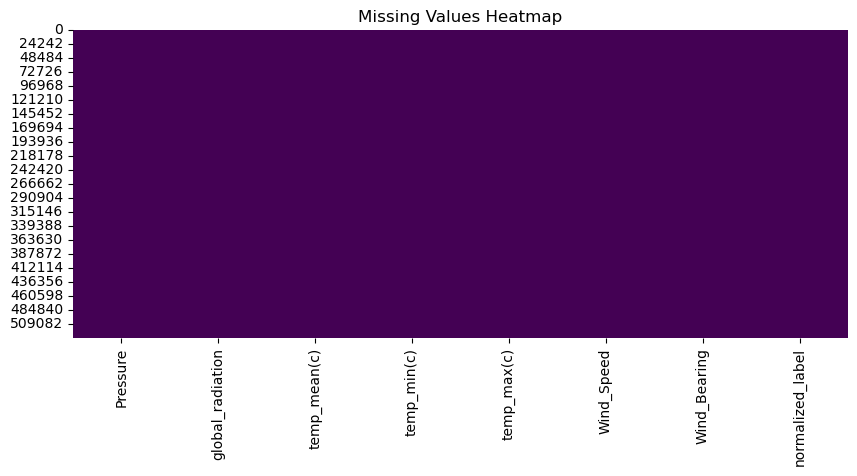

In [12]:
plt.figure(figsize=(10, 4))
sns.heatmap(weather.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

Text(0.5, 1.0, 'Distribution of Weather Conditions')

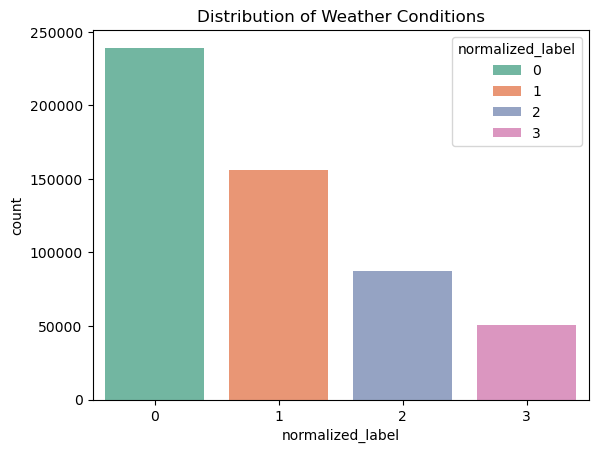

In [14]:
sns.countplot(x="normalized_label", data=weather,hue="normalized_label", palette="Set2" )
plt.title("Distribution of Weather Conditions")

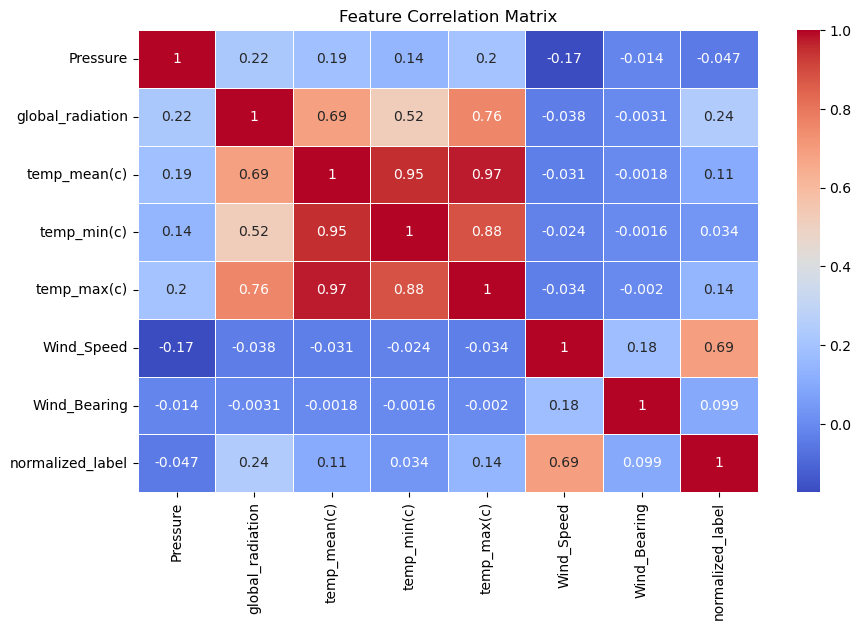

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(weather.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train) 
X_test = sc.transform(X_test) 

In [26]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9989312132604559
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47804
           1       1.00      1.00      1.00     31148
           2       1.00      1.00      1.00     17506
           3       1.00      1.00      1.00     10205

    accuracy                           1.00    106663
   macro avg       1.00      1.00      1.00    106663
weighted avg       1.00      1.00      1.00    106663



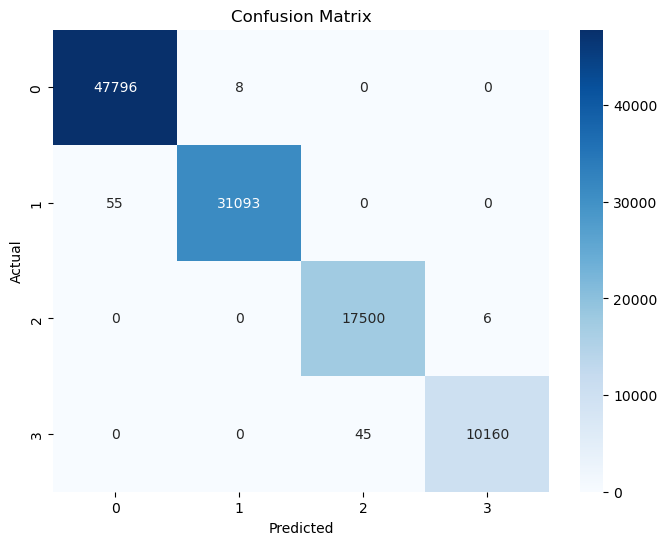

In [30]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

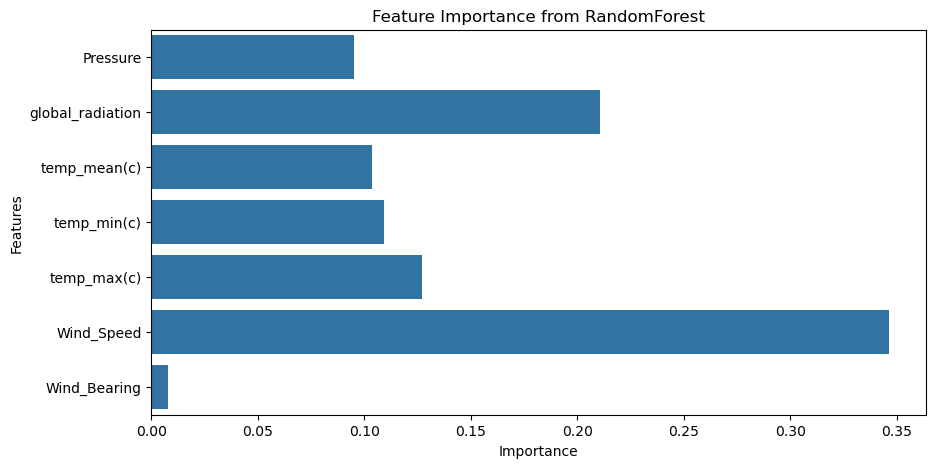

In [31]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance from RandomForest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()